Inicialmente é realizado a instalação necessária e a importação das bibliotecas importantes para rodar o código

In [ ]:
%%capture
!pip install qiskit[visualization]==1.2.2
!pip install qiskit_aer
!pip install qiskit_ibm_runtime
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 5.6 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=f310d76319635d8eda3749e25be09b324dd82f95a66a64dc3b5bc780e7191c4b
  Stored in directory: /root/.cache/pip/wheels/d3/31/8b/e09b0386afd80cfc556c00408c9aeea5c35c4d484a9c762fd5
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Importe as bibliotecas necessárias para executar o projeto.
import qiskit
import numpy as np
import matplotlib.pyplot as plt
import qiskit.quantum_info as qi

In [ ]:
from qiskit import *
from qiskit import QuantumRegister, ClassicalRegister
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from numpy import pi
from math import sqrt
from qiskit.visualization import plot_bloch_multivector

O código a seguir apresenta o registro dos qubits de Alice
e Bob, e o registro do bit clássico no qual Bob armazena o resultado
da medida feita no seu estado recebido.

In [ ]:
Alice = QuantumRegister(2, 'alice')
Bob = QuantumRegister(1, 'bob')
b = ClassicalRegister(1, 'c_bob')

Em seguida é feita a inicialização do estado que será teleportado por Alice.

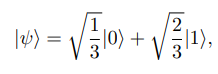

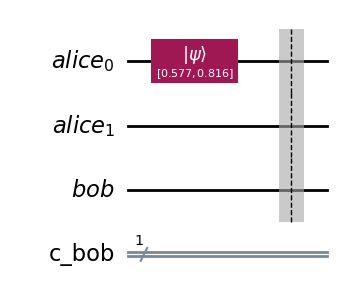

In [ ]:
teleporte = QuantumCircuit(Alice,Bob,b)
estado_inicial = [np.sqrt(1/3),np.sqrt(2/3)]
teleporte.initialize(estado_inicial,Alice[0])
teleporte.barrier()
teleporte.draw('mpl')

O próximo passo é emaranhar o qubit auxiliar de
Alice com o qubit de Bob em um dos Estados de Bell
apresentados, usando o circuito quântico
gerador de estados quânticos emaranhado para 2 qubits.

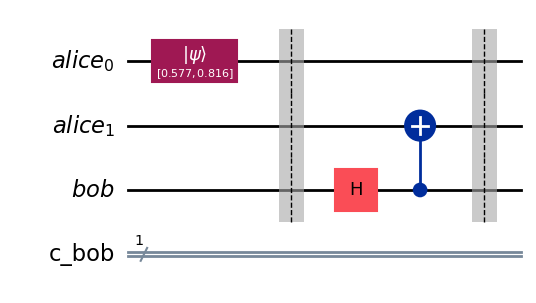

In [ ]:
teleporte.h(Bob[0])
teleporte.cx(Bob[0],Alice[1])
teleporte.barrier()
teleporte.draw('mpl')

Em seguida, Alice inicia o processo de envio do estado
preparado.

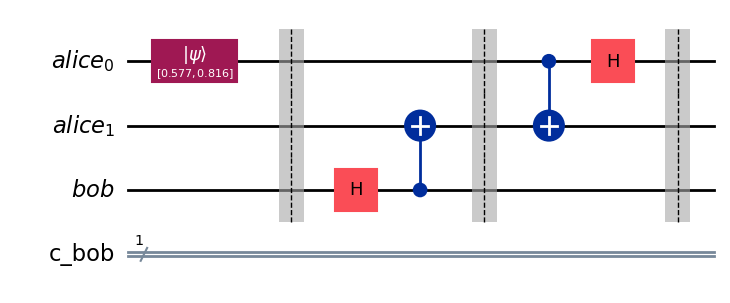

In [ ]:
teleporte.cx(Alice[0],Alice[1])
teleporte.h(Alice[0])
teleporte.barrier()
teleporte.draw('mpl')

No protocolo original, o próximo passo seria
Alice realizar medidas em seus qubits e, a depender
dos resultados, entrar em contato com Bob através
de um canal clássico para informar as correções que
Bob deve aplicar em seu estado para que o teleporte
seja executado e ele consiga resgatar o estado enviado
por Alice. Esse passo pode ser executado através de
uma operação condicionada ao resultado das medidas
de Alice. Nesse caso, podemos substituí-la pela porta CNOT e Z-Controlada (construída a partir da
combinação das portas Hadamard e CNOT ou seja Z = HXH.). Assim, conseguimos modificar
o circuito original sem mudar seu objetivo.

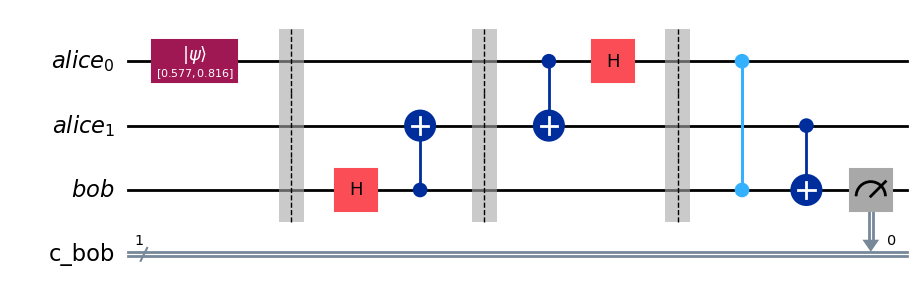

In [ ]:
#teleporte.h(Bob[0])
#teleporte.cx(Alice[0], Bob[0])
#teleporte.h(Bob[0])
teleporte.cz(Alice[0], Bob[0])
teleporte.cx(Alice[1], Bob[0])
teleporte.measure(Bob, b)
teleporte.draw(output = 'mpl')

Ao final do processo, realizamos uma medida no qubit de Bob e obtemos a distribuição de probabilidade correspondente.

In [ ]:
# Use o simulador Qiskit Aer para executar o circuito
simulator = AerSimulator()
compiled_circuit = transpile(teleporte, simulator)
result = simulator.run(compiled_circuit).result()

In [ ]:
# Obtenha a contagem dos resultados
counts = result.get_counts()
print("Counts:", counts)

Counts: {'1': 671, '0': 353}


A Figura abaixo apresenta a distribuição de probabilidade para o qubit de Bob após a realização do circuito em um processador quântico real.

{'1': 671, '0': 353}


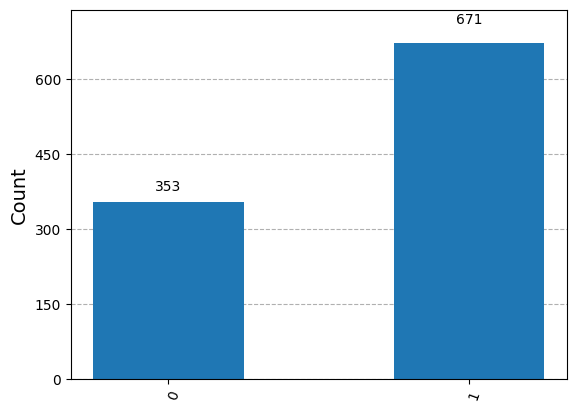

In [ ]:
# Mostrar resultados
print(counts)
plot_histogram(counts)

Como pode ser visto, nota-se que o estado medido
no qubit de Bob foi, em boa aproximação, o estado
enviado por Alice, conforme a equação inicial. O valor apresentado está de acordo com a margem de erro esperada para o algoritmo de teleporte, executado no processador IBM QE de 5 qubits, conforme reportado
na literatura.